# Data Exploration and Cleaning Analysis

This notebook explores raw data anomalies to establish the cleaning logic used in the `DataCleanse-Lite` ETL pipeline. We use visual exploratory data analysis (EDA) to expose missing values, outliers, and formatting issues.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the raw data
df = pd.read_csv('../data/unprocessed/sales_dump_1.csv')
df.head()

,Transaction ID,CUSTOMER_ID,product-id,timestamp,Amount,currency
0,a82bd882-8893-4b08-bcda-823d968eb59c,CUST_2806,PROD_35,2026-04-13T19:17:42.509274,229.62,NaN
1,a6a8e2b3-4716-451b-aac3-815951c44d16,CUST_8337,PROD_60,2026-03-18T19:17:42.509362,277.49,EUR
2,e011cbf6-91ad-4b04-8f10-1b73cccf3601,CUST_2771,PROD_97,2026-08-08T19:17:42.509381,6.92,EUR
3,9264bf5e-b2b2-4717-bb1a-54d7783911be,CUST_7269,PROD_54,2026-02-15T19:17:42.509401,348.92,usd
4,b0f9cfeb-a850-4823-bd2a-8b148c13b228,CUST_5414,PROD_31,2026-07-09T19:17:42.509419,51.35,NaN


### 1. Identifying Missing Data
The horizontal bar chart below visualizes the percentage of missing data across columns. We also print the exact count of missing values per column.

Missing Value Counts:
Transaction ID         0
CUSTOMER_ID          558
product-id             0
timestamp              0
Amount              2384
currency           10100
dtype: int64


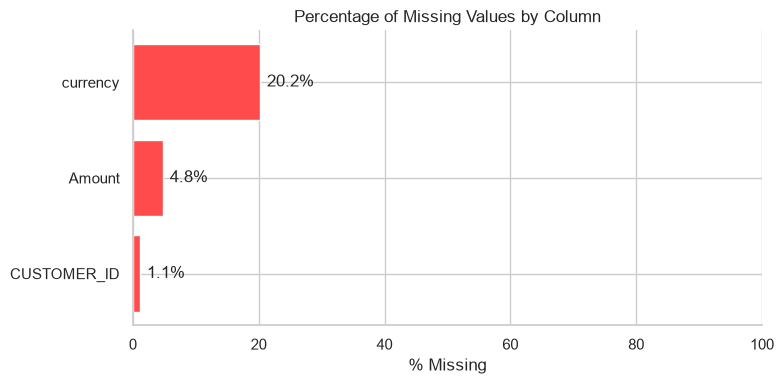

In [19]:
# Print exact counts
print("Missing Value Counts:")
print(df.isnull().sum())

# Calculate missing percentages
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)

if not missing_pct.empty:
    plt.figure(figsize=(8, 4))
    bars = plt.barh(missing_pct.index, missing_pct.values, color='#FF4B4B')

    # Add percentage labels to bars
    plt.bar_label(bars, fmt='%.1f%%', padding=5)
    plt.xlim(0, 100)
    plt.xlabel('% Missing')
    plt.title('Percentage of Missing Values by Column', fontsize=12)
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

### 2. Transaction Amount Distribution
Understanding the spread of transaction amounts helps us identify if there are wild outliers or if missing values should be imputed with 0.0.

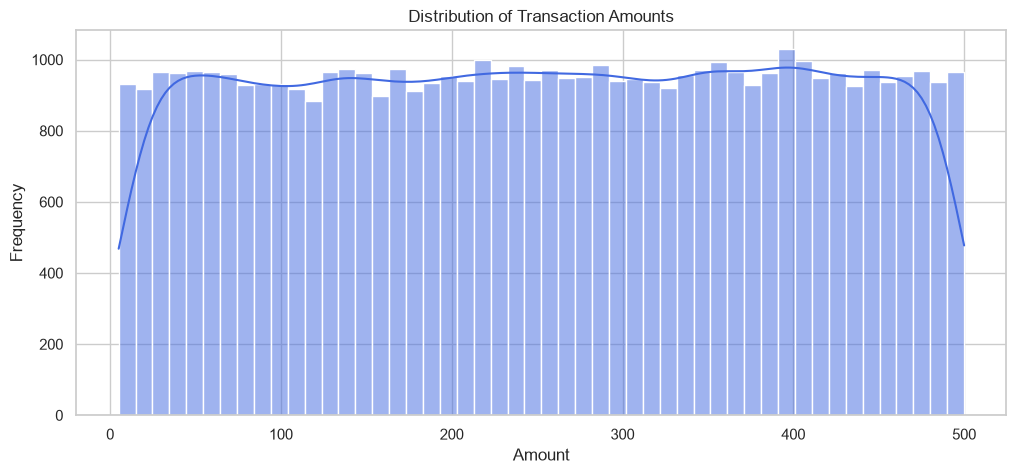

In [20]:
# Convert 'Amount' to numeric temporarily for visualization
temp_amount = pd.to_numeric(df['Amount'], errors='coerce').dropna()

plt.figure(figsize=(12, 5))
sns.histplot(temp_amount, bins=50, kde=True, color='royalblue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

### 3. Visualizing Categorical Messiness (Currency)
This chart exposes why text standardization is crucial. Raw data contains spaces, mixed casings, and empty values that must be handled by the pipeline.

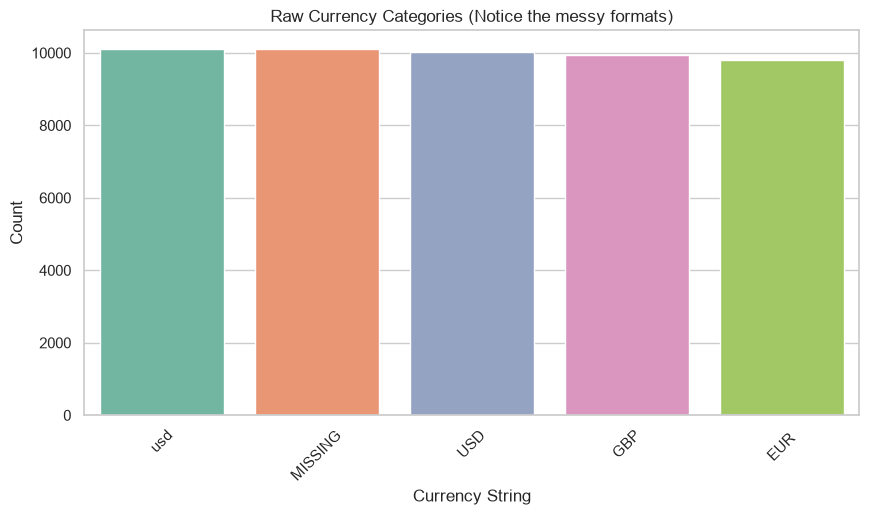

In [21]:
plt.figure(figsize=(10, 5))

# Fill NA temporarily so we can see 'MISSING' as a category on the chart
currency_counts = df['currency'].fillna('MISSING').value_counts()

sns.barplot(x=currency_counts.index, y=currency_counts.values, hue=currency_counts.index, legend=False, palette='Set2')
plt.title('Raw Currency Categories (Notice the messy formats)')
plt.xlabel('Currency String')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 4. Exploring Data Types and Formatting
We can see raw data column names are unstandardized (spaces, mixed casing) and data types may be loaded as generic `object` types.

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction ID   50000 non-null  str    
 1   CUSTOMER_ID      49442 non-null  str    
 2   product-id       50000 non-null  str    
 3   timestamp        50000 non-null  str    
 4   Amount           47616 non-null  float64
 5   currency         39900 non-null  str    
dtypes: float64(1), str(5)
memory usage: 2.3 MB


### Conclusion for ETL Rules
- **Standardization:** Column headers must be forced to lower snake_case and stripped of whitespace/punctuation.
- **Imputation:** Null `Amount` values should be padded to 0.0 to prevent sum errors in downstream marts.
- **Text Formatting:** Categorical strings like `currency` must be `STRIP()`ped and capitalized.
- **Validation:** Missing `CUSTOMER_ID` and invalid timestamps should be quarantined via Pydantic schemas.